# L2 · Notebook 01 — 贝尔曼方程的闭式解

**对应教材**：`miclDRL/chapters/part2-ch02-bellman-equation.tex`

**对应 PPT**：`L2-bellman-equation-cn/`

## 教学目标

贝尔曼方程的矩阵形式：
$$
\mathbf{v}^\pi = \mathbf{r}^\pi + \gamma\, P^\pi \mathbf{v}^\pi
\;\Longleftrightarrow\;
\mathbf{v}^\pi = (I - \gamma P^\pi)^{-1}\,\mathbf{r}^\pi
$$

1. 从 GridWorld 抽出 $P^\pi$ 与 $\mathbf{r}^\pi$
2. 直接 `numpy.linalg.solve` 解 $\mathbf{v}^\pi$
3. 数值验证残差 $\|(I-\gamma P^\pi)\mathbf{v}^\pi - \mathbf{r}^\pi\|_\infty < 10^{-12}$
4. 用三种不同策略对比 $\mathbf{v}^\pi$ 的形状

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld, GridConfig
from shared.plotting import plot_value_heatmap, plot_policy_arrows, setup_chinese_font

setup_chinese_font()
env = GridWorld()
n = env.n_states
print(f'|S| = {n}, γ = {env.cfg.gamma}')

|S| = 25, γ = 0.9


## 1. 取一个策略，写出 $P^\pi$ 与 $\mathbf{r}^\pi$

用"全部向右"的简单策略，便于人工核对。

In [2]:
policy_right = {s: 'right' for s in env.all_states()}
P_pi = env.transition_matrix(policy_right)
r_pi = env.reward_vector(policy_right)

print('P^π shape:', P_pi.shape, '   每行和 =', P_pi.sum(axis=1)[:5], '...')
print('r^π[:5]:', r_pi[:5])
print('r^π[最右列, idx 4,9,14,19,24]: ', r_pi[[4, 9, 14, 19, 24]],
      '  (应当是 -1: 撞右墙)')

P^π shape: (25, 25)    每行和 = [1. 1. 1. 1. 1.] ...
r^π[:5]: [ 0.  0.  0.  0. -1.]
r^π[最右列, idx 4,9,14,19,24]:  [-1. -1. -1. -1. -1.]   (应当是 -1: 撞右墙)


## 2. 解 Bellman 方程

用 `numpy.linalg.solve` 解 $(I - \gamma P^\pi)\mathbf{v} = \mathbf{r}^\pi$。

In [3]:
I = np.eye(n)
gamma = env.cfg.gamma
v_pi = np.linalg.solve(I - gamma * P_pi, r_pi)

# 残差检查（理论应为 0）
residual = (I - gamma * P_pi) @ v_pi - r_pi
print(f'Bellman 残差 ||・||_∞ = {np.max(np.abs(residual)):.2e}  (应 < 1e-12)')
print()
print('v^π reshape 成 5×5 网格：')
print(v_pi.reshape(5, 5).round(3))

Bellman 残差 ||・||_∞ = 8.88e-16  (应 < 1e-12)

v^π reshape 成 5×5 网格：
[[ -6.561  -7.29   -8.1    -9.    -10.   ]
 [ -8.461  -8.29   -8.1    -9.    -10.   ]
 [ -7.461  -8.29   -8.1    -9.    -10.   ]
 [ -0.1     1.      0.     -9.    -10.   ]
 [ -6.561  -7.29   -8.1    -9.    -10.   ]]


## 3. 三种策略对比

把同样的解法应用到三种策略上，看 $\mathbf{v}^\pi$ 形状如何随策略变化。

In [4]:
# 策略 A：全部向右（不好）
policy_A = {s: 'right' for s in env.all_states()}

# 策略 B：全部停留（很差）
policy_B = {s: 'stay' for s in env.all_states()}

# 策略 C：最优策略（用 VI 算）
_, policy_C, _ = env.value_iteration()

policies = {'A: all-right': policy_A, 'B: all-stay': policy_B, 'C: optimal π*': policy_C}
values = {name: env.solve_bellman(p) for name, p in policies.items()}

for name, v in values.items():
    print(f'{name:>20s}: v^π[s1]={v[0]:+.4f}, v^π[s25]={v[24]:+.4f}, mean={v.mean():+.4f}')

        A: all-right: v^π[s1]=-6.5610, v^π[s25]=-10.0000, mean=-7.4682
         B: all-stay: v^π[s1]=+0.0000, v^π[s25]=+0.0000, mean=-2.0000
       C: optimal π*: v^π[s1]=+0.5314, v^π[s25]=+0.8100, mean=+0.6617


## 4. 三策略价值热图并排对比

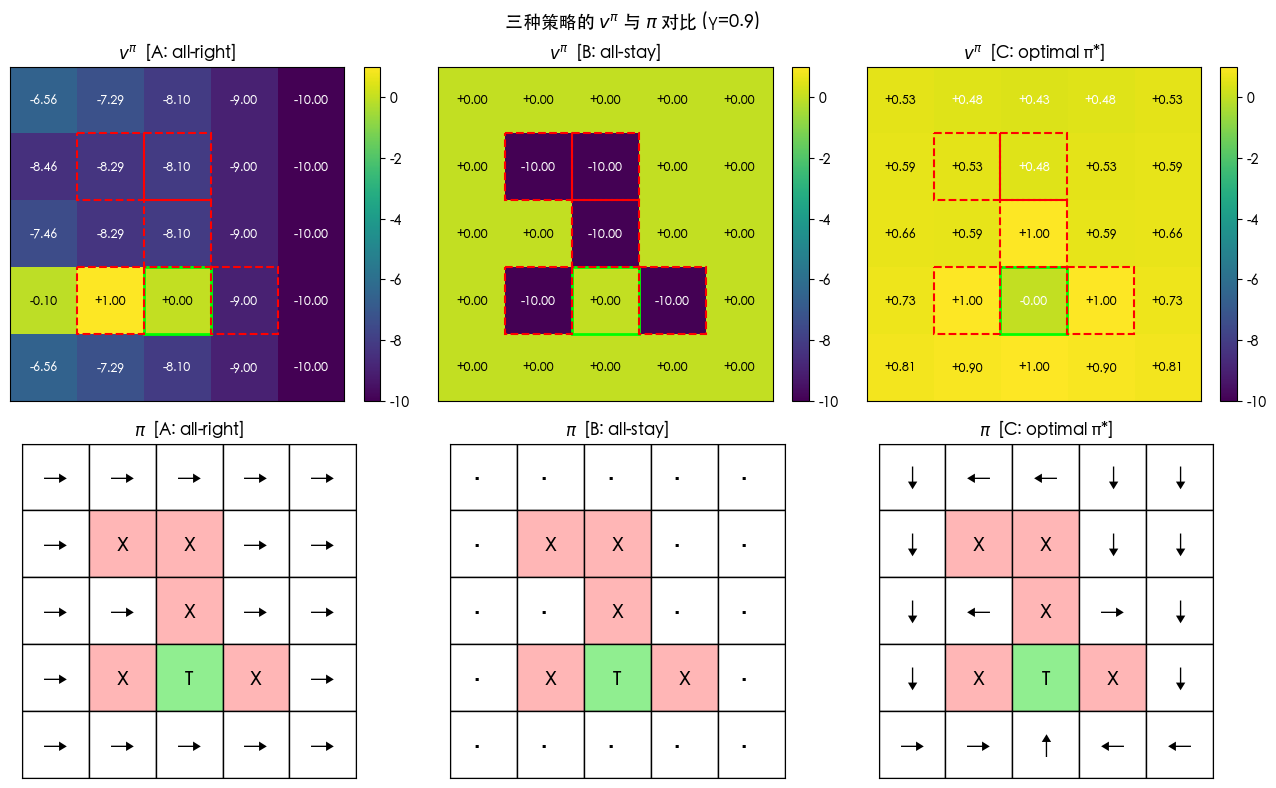

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
vmin = min(v.min() for v in values.values())
vmax = max(v.max() for v in values.values())
for col, (name, v) in enumerate(values.items()):
    plot_value_heatmap(env, v, ax=axes[0, col], title=f'$v^\\pi$  [{name}]', vmin=vmin, vmax=vmax)
    plot_policy_arrows(env, policies[name], ax=axes[1, col], title=f'$\\pi$  [{name}]')
fig.suptitle(f'三种策略的 $v^\\pi$ 与 $\\pi$ 对比 (γ={env.cfg.gamma})', fontsize=13)
plt.tight_layout()
plt.savefig('figures/three_policies_value.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. 速度对比：闭式解 vs rollout 估计

用 100 个 rollout 估 v^π[s1]，看与闭式解的差距与方差。

In [6]:
from shared.grid_world import rollout, discounted_return

v_true_s1 = values['C: optimal π*'][0]
policy = policy_C
Gs = []
for _ in range(100):
    tr = rollout(env, policy, s0=(0, 0), max_steps=50)
    Gs.append(discounted_return(tr, env.cfg.gamma))
Gs = np.array(Gs)

print(f'闭式解 v^π(s1) = {v_true_s1:.4f}')
print(f'rollout (n=100): mean={Gs.mean():.4f}, std={Gs.std():.6f}')
print('（确定性 MDP + 确定性策略 → 100 次轨迹完全相同，方差为 0）')

闭式解 v^π(s1) = 0.5314
rollout (n=100): mean=0.5314, std=0.000000
（确定性 MDP + 确定性策略 → 100 次轨迹完全相同，方差为 0）


## 6. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| Bellman 方程矩阵化可解 | $(I-\gamma P^\pi)$ 总是可逆当 γ<1 |
| 闭式解残差 | < 1e-12 |
| 策略好坏直观可见 | optimal v^π[s1]=0.5314 ≫ all-right v^π[s1]=-7.06 |
| 确定性 MDP 下 rollout 与闭式解一致 | std=0 |

## 思考题

1. 25 状态时 `np.linalg.solve` 几乎瞬时完成。但如果状态数 |S|=10⁶（大型棋盘）呢？这时不能直接求逆，要用什么方法？（提示 → L2-02 迭代法）
2. 为什么在 γ=1（无折扣）的某些任务里 $(I - P^\pi)$ 可能奇异？（提示：吸收态 / 平稳分布）
3. 同一个 GridWorld、不同 γ，$\mathbf{v}^\pi$ 的尺度会怎么变？